# Sincere/Insincere Questions Dataset

This is the reference of my daatset:

https://huggingface.co/datasets/UKPLab/insincere-questions/tree/main

Import the needed libraries:

In [1]:
#%pip install gensim

In [2]:
import numpy as np
import pandas as pd
import re   #regular expression in python ,removes all punctuation from a string
import random #Generates random values used for data augmentation
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import seaborn as sns


import nltk #Natural Language Toolkit, a library for NLP tasks like tokenization (divide the phrase into subwords)
from nltk.corpus import stopwords   #predefined list of common English words that are usually not useful for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer #Converts text into numerical vectors based on word importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences #Ensures all text sequences have the same length by padding
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, regularizers, models


import pickle #Serializes Python objects such as tokenizers for later reuse in deployment.


np.random.seed(42)
tf.random.set_seed(42)

## Dataset Understanding & Cleaning
1. we need to read the data from pandas library

In [3]:
train = pd.read_json("train.jsonl", lines=True)
test = pd.read_json("test.jsonl", lines=True)
validation = pd.read_json("val.jsonl", lines=True)
train.head()


,qid,text,labels,label_text
0,155730364d2eebd51c87,How do people in the desert control their swea...,0,valid question
1,efe401bafc26b533e27c,What's the most embarrassing thing you've done...,0,valid question
2,827ace5be842d46c6040,Which book should I refer to for UPSC Mains so...,0,valid question
3,4957b6c4b52c3b6cb8e0,Do Germany and Russia have an agreement to coo...,0,valid question
4,6994a6944942dc435128,What gpu and motherboard should I go pair with...,0,valid question


since the dataset is downloaded as json files not csv files so i need to read it as json too

2. we need to understand the dataset

In [4]:
train.columns

Index(['qid', 'text', 'labels', 'label_text'], dtype='object')

Here we have 4 columns:
- QID -> the question ID which i see that is not that important and can be dropped when i do the cleaning part
- Text -> the most important column because this is from where the DL model will derect if the dataset is sincere/incincere
- Labels -> is also important because this dataset is used for classification so 0 will be considered as sincere or incincere and 1 will be considered as the other (we will see in data understanding)
- label_text -> i see that is not important also because it's written valid/invalid question which is based on the text and which can also be expressed by the labels (will be dropped)

In [5]:
train.head(10)


,qid,text,labels,label_text
0,155730364d2eebd51c87,How do people in the desert control their swea...,0,valid question
1,efe401bafc26b533e27c,What's the most embarrassing thing you've done...,0,valid question
2,827ace5be842d46c6040,Which book should I refer to for UPSC Mains so...,0,valid question
3,4957b6c4b52c3b6cb8e0,Do Germany and Russia have an agreement to coo...,0,valid question
4,6994a6944942dc435128,What gpu and motherboard should I go pair with...,0,valid question
5,467d5a7f36c0b4ae7674,Could these scenarios happen of time travel co...,0,valid question
6,941367c970ac5b678de2,What would English be like if it followed the ...,0,valid question
7,b0c4ed8d85ac2c650d97,Is there a software package to manage database...,0,valid question
8,3ca5eb8d15cc7173218f,How did you deal with chronic prostatis/chroni...,0,valid question
9,c1ba823ec32bdb72f3a9,Is there a tool that works like a marker but h...,0,valid question


So right now we know that 0 stands for sincere question (thanks to the label_text) and 1 stands for incincere question

In [6]:
print(train['labels'].value_counts())
print("Total questions:", len(train))


labels
0    1178416
1      77706
Name: count, dtype: int64
Total questions: 1256122


this tells that there is about 1178416 sincere questions and 77706 incincere questions
and total questions of the dataset is 1256122 question 
And actually this is a big problem -> 'DATA IMBALANCE'

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256122 entries, 0 to 1256121
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   qid         1256122 non-null  object
 1   text        1256122 non-null  object
 2   labels      1256122 non-null  int64 
 3   label_text  1256122 non-null  object
dtypes: int64(1), object(3)
memory usage: 38.3+ MB


there is 0 nulls in the dataset which is something good and i have 2 data types (object -> means string / int)

In [8]:
train.sample(5)

,qid,text,labels,label_text
290007,51a80e7471e831a4625a,What made you become an atheist & are you stil...,0,valid question
957357,390ed71cb679c207f1dc,Where can I download test bank for accounting ...,0,valid question
578781,10412229bf9828df24a5,Can antibody gene be an example for selfish gene?,0,valid question
1242177,096220c71827eb819b76,"Where can I find tutorial or lecture for ""aho ...",0,valid question
1143533,ebbb24193c1fdb290590,What do podiatrists think of Tom's shoes for t...,0,valid question


In [9]:
train.describe()

,labels
count,1.256122e+06
mean,6.186183e-02
std,2.409045e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.000000e+00


here there is only 1 column because this is the only column to be considered as integer .. other than that all of them are strings  and the mean represent that 6.1% of the data is sincere

In [10]:
train.isna().sum()

qid           0
text          0
labels        0
label_text    0
dtype: int64

to make sure that there is no nulls

In [11]:
print(validation.columns)
print(test.columns)

Index(['qid', 'text', 'labels', 'label_text'], dtype='object')
Index(['qid', 'text', 'labels', 'label_text'], dtype='object')


In [12]:
print(validation.count())
print(test.count())

qid           2500
text          2500
labels        2500
label_text    2500
dtype: int64
qid           47500
text          47500
labels        47500
label_text    47500
dtype: int64


this means that the validation is only be 2500 questions
and the test is 47500.
the validation count is << than the test count to quickly check performance while training and change the parameters

3. we need to clean the dataset

In [13]:
train = train.drop(columns=['qid', 'label_text'], errors='ignore')
test = test.drop(columns=['qid', 'label_text'], errors='ignore')
validation = validation.drop(columns=['qid', 'label_text'], errors='ignore')
# ignore is ignore the error if the column doesn't exsist


dropped the columns that had no importance
- dropped qid because it makes no sense to have every sentence's id
- dropped label_text because i already have the labels which tells if the sentence is sincere/ insincere provided as 0/1

In [14]:
train['labels'].value_counts()


labels
0    1178416
1      77706
Name: count, dtype: int64

The dataset suffers from severe class imbalance, with sincere questions (label 0) significantly outnumbering insincere questions (label 1). This imbalance can cause the model to develop a bias toward predicting the majority class. -> will add data augmentation / sampling of the data

In [15]:
#%pip install nltk

In [16]:
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = " ".join(word for word in text.split() if word not in STOPWORDS)
    return text

train['clean_text'] = train['text'].apply(clean_text)
validation['clean_text'] = validation['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\layla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


- All text is lowercased.

- All punctuation is removed.

- Stopwords are removed (the , is , and , to).

- A new column clean_text contains the cleaned text for modeling.

this is so important because for the model if the text is lowecased it will be different than when it is not same goes for punctuation and stopwords 

In [17]:
print(train.columns)
print(validation.columns)
print(test.columns)


Index(['text', 'labels', 'clean_text'], dtype='object')
Index(['text', 'labels', 'clean_text'], dtype='object')
Index(['text', 'labels', 'clean_text'], dtype='object')


In [18]:
train[['text','clean_text','labels']].head(10)


,text,clean_text,labels
0,How do people in the desert control their swea...,people desert control sweating,0
1,What's the most embarrassing thing you've done...,whats embarrassing thing youve done win prize,0
2,Which book should I refer to for UPSC Mains so...,book refer upsc mains solved previous question...,0
3,Do Germany and Russia have an agreement to coo...,germany russia agreement cooperate finding ret...,0
4,What gpu and motherboard should I go pair with...,gpu motherboard go pair x5460 budget 175 eur b...,0
5,Could these scenarios happen of time travel co...,could scenarios happen time travel comes exist...,0
6,What would English be like if it followed the ...,would english like followed grammar german,0
7,Is there a software package to manage database...,software package manage database server config...,0
8,How did you deal with chronic prostatis/chroni...,deal chronic prostatischronic pelvic pain diso...,0
9,Is there a tool that works like a marker but h...,tool works like marker acrylic paint inside,0


as we can see here the clean text is way more better, there is no stop words, all words are in lower case (maybe this will make it easier to the model to train)
right now i can remove text .. becuase i have another clean version without punctuations,etc...

In [19]:
train.drop(columns='text', inplace=True)
test.drop(columns='text', inplace=True)
validation.drop(columns='text', inplace=True)

In [20]:
print(train.columns)
print(validation.columns)
print(test.columns)


Index(['labels', 'clean_text'], dtype='object')
Index(['labels', 'clean_text'], dtype='object')
Index(['labels', 'clean_text'], dtype='object')


so right now i have only 2 columns labels and clean_text but i need to put clean_text first then labels

In [21]:
train = train[['clean_text', 'labels']]
test = test[['clean_text', 'labels']]
validation = validation[['clean_text', 'labels']]

train.head()


,clean_text,labels
0,people desert control sweating,0
1,whats embarrassing thing youve done win prize,0
2,book refer upsc mains solved previous question...,0
3,germany russia agreement cooperate finding ret...,0
4,gpu motherboard go pair x5460 budget 175 eur b...,0


#### Done for data preparation

## EDA & Visualization

In [22]:

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['loss'], label='train_loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(history.history['accuracy'], label='train_accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if i want to plot the training_accuracy and the validation_accuracy , training_loss and validation_loss to compare between them instead of writing the code 100 times i did a function and when i want to plot, i will just use that function

In [23]:
print("Label distribution:\n", train['labels'].value_counts())
print("\nPercentage per class:\n", train['labels'].value_counts(normalize=True) * 100)


Label distribution:
 labels
0    1178416
1      77706
Name: count, dtype: int64

Percentage per class:
 labels
0    93.813817
1     6.186183
Name: proportion, dtype: float64


this is a statistical summary of the dataset that i have .. 93.8% of the data is sincere and the other 6.1% of the data is insincere which tells that there is very big data imbalance

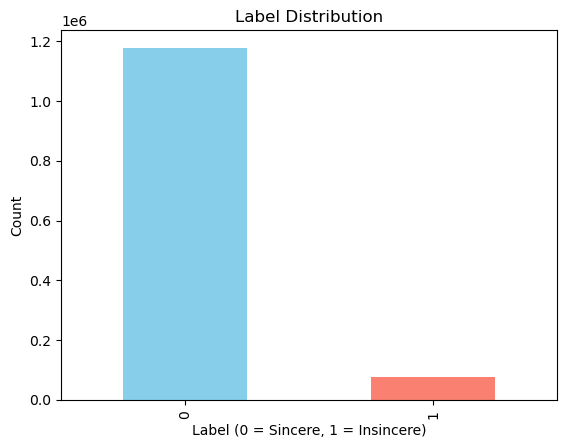

In [24]:
train['labels'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Label Distribution")
plt.xlabel("Label (0 = Sincere, 1 = Insincere)")
plt.ylabel("Count")
plt.show()

Here after getting the value counts of both (sincere/insincere) i plotted them into 2 bars and as we can see here the bar of the sincere is way more bigger than the insincere one

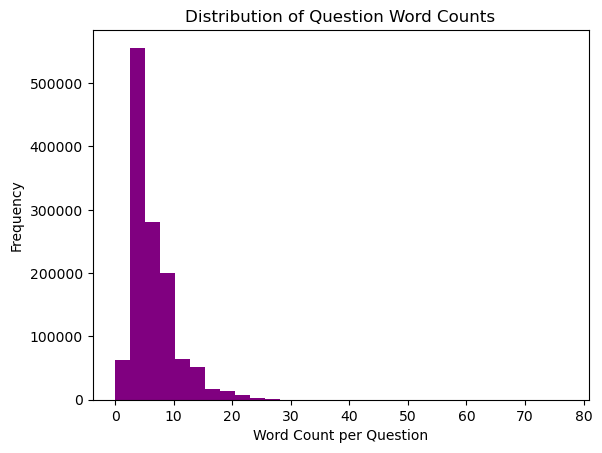

In [25]:
plt.hist(train['clean_text'].apply(lambda x: len(x.split())), bins=30, color='purple')
plt.title("Distribution of Question Word Counts")
plt.xlabel("Word Count per Question")
plt.ylabel("Frequency")
plt.show()

This shows how long is the text length in sentences of the datasset to do that i used the lambda function that splits the sentences into words (after cleaning them for sure) to a series of numbers where each number represent the word count of the question

-- the graph says that the words per question are between 1 and 5 words but most of the questions contain 5 words or more like 6 or 7

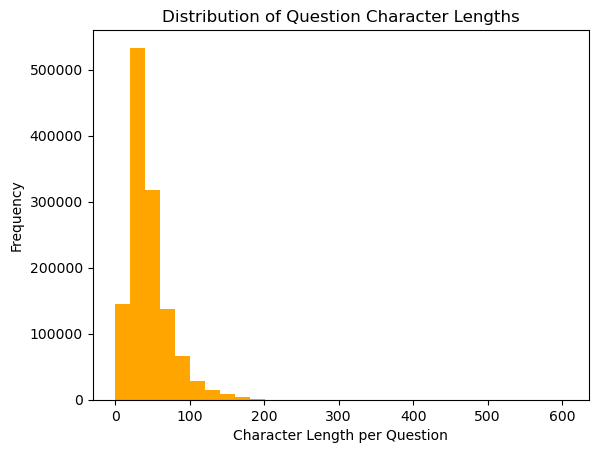

In [26]:
plt.hist(train['clean_text'].apply(len), bins=30, color='orange')
plt.title("Distribution of Question Character Lengths")
plt.xlabel("Character Length per Question")
plt.ylabel("Frequency")
plt.show()


This is the same graph as before but here i count the character length per question 
-- the graph says that the characters per question are between 1 and 5 words but most of the questions contain 5 words or more like 6 or 7

VECTOR-BASED TEXT ANALYSIS
Creating TF-IDF vectors...
TF-IDF matrix shape: (1256122, 1000)
Reducing dimensions with PCA...


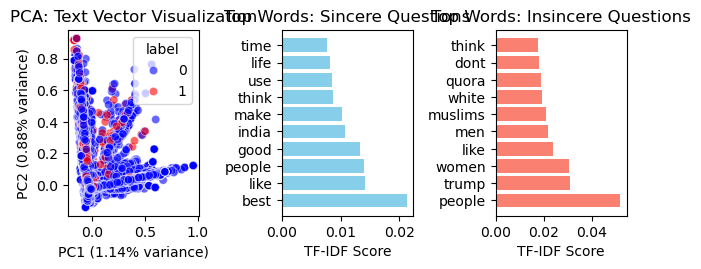

In [ ]:
print("VECTOR-BASED TEXT ANALYSIS") #convert words into vectors so statistical and visual analysis can be performed.

# Create TF-IDF vectors
print("Creating TF-IDF vectors...") # convert each text sample to numerical vector
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')  # keeps Top 1000 most important words
X_tfidf = tfidf.fit_transform(train['clean_text'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}") #(number of samples x 1000features)

# Reduce dimensions for visualization using PCA from 1000 dimensional vector to 2 dimensions
print("Reducing dimensions with PCA...")
pca = PCA(n_components=2, random_state=42) 
X_pca = pca.fit_transform(X_tfidf.toarray())

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = train['labels'].values

# 4. PCA visualization of text vectors
plt.subplot(2, 3, 4)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', alpha=0.6, palette=['blue', 'red'])
plt.title("PCA: Text Vector Visualization")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")

# 5. Most important words by class
plt.subplot(2, 3, 5)

# Get top words for each class
def get_top_words_by_class(class_label, top_n=10):
    class_indices = train[train['labels'] == class_label].index
    class_tfidf = X_tfidf[class_indices]
    word_scores = np.asarray(class_tfidf.mean(axis=0)).flatten()
    top_indices = word_scores.argsort()[-top_n:][::-1]
    top_words = [tfidf.get_feature_names_out()[i] for i in top_indices]
    top_scores = [word_scores[i] for i in top_indices]
    return top_words, top_scores

# Plot top words for sincere questions (class 0)
top_words_0, scores_0 = get_top_words_by_class(0)
plt.barh(range(len(top_words_0)), scores_0, color='skyblue')
plt.yticks(range(len(top_words_0)), top_words_0)
plt.title("Top Words: Sincere Questions")
plt.xlabel("TF-IDF Score")

# 6. Most important words for insincere questions (class 1)
plt.subplot(2, 3, 6)
top_words_1, scores_1 = get_top_words_by_class(1)
plt.barh(range(len(top_words_1)), scores_1, color='salmon')
plt.yticks(range(len(top_words_1)), top_words_1)
plt.title("Top Words: Insincere Questions")
plt.xlabel("TF-IDF Score")

plt.tight_layout()
plt.show()

the TF-IDF convert each text into a numerical vector so that each dimension represents a word an then draw on a graph which words are the most common-> tf: how often the word apears in the document , idf: how rare the word is accross all documents

and used pca to reduce the dimension because the TF-IDF is impossible to draw 1000 number so we need to reduce the dimension to 2

as we can see in the left graph:
this is after using pca and converts the numbers into dots of the sincere and insincere .. the blue represent the sincere and this is pretty obvious because in my dataset the sincere was actually >>> than the insincere

as we can see in the right graph :
best is the most word that appear in sincere questions , and people is the most common word that appear in the insincere questions and for the opposite the least common of sincere question is time and for the insincere question is think

CORRELATION ANALYSIS WITH TEXT FEATURES


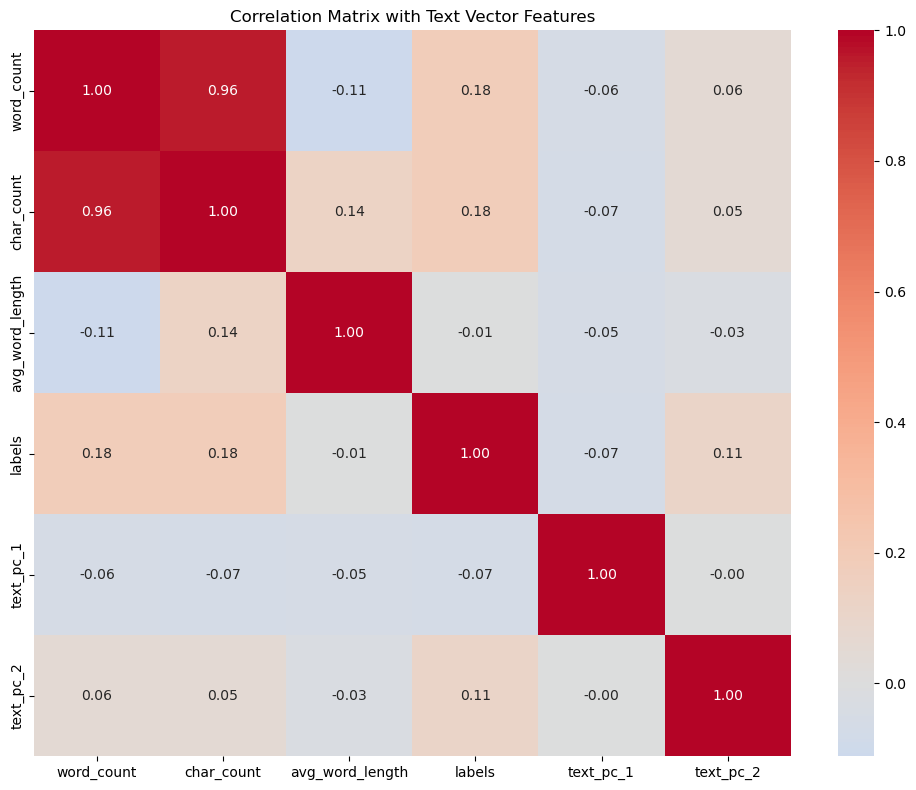

Correlation with labels:
labels             1.000000
char_count         0.184755
word_count         0.181112
text_pc_2          0.114022
avg_word_length   -0.007261
text_pc_1         -0.065047
Name: labels, dtype: float64


In [28]:
print("CORRELATION ANALYSIS WITH TEXT FEATURES")
# Create meaningful features for correlation analysis
train_features = train.copy()
train_features['word_count'] = train_features['clean_text'].apply(lambda x: len(x.split()))
train_features['char_count'] = train_features['clean_text'].apply(len)
train_features['avg_word_length'] = train_features['clean_text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0)

# Add TF-IDF based features (using the first few components)
for i in range(min(3, X_pca.shape[1])):
    train_features[f'text_pc_{i+1}'] = X_pca[:, i]

# Create meaningful correlation matrix
correlation_features = ['word_count', 'char_count', 'avg_word_length', 'labels']
if 'text_pc_1' in train_features.columns:
    correlation_features.extend(['text_pc_1', 'text_pc_2']) #Numbers that describe the general word pattern of the question

corr_matrix = train_features[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Matrix with Text Vector Features")
plt.tight_layout()
plt.show()

print("Correlation with labels:")
print(corr_matrix['labels'].sort_values(ascending=False))

the code above explain which text characteristics are related to whether a question is sincere or insincere.

this correlation matrix represent : +1 → strong positive relationship
0 → no relationship
-1 → strong negative relationship

so as we can see we have very big relation between the word count and the character count = 0.96 and for sure the diagonal will be 1 because am comparing the relation between sometinh and itself


and the highest correlation with labels is the char_count which represent 0.1847 the highest of them all and for the opposite relation we have 2 : avg_word_length and text_pc_1

## Preprocesing & Tokenization

will add data augmentation -> exchange the positions of 2 random words in a sentence , and remove words with 10% probability to imporve the model generalization  

In [29]:
print("Before augmentation:")
print("Label distribution:\n", train['labels'].value_counts())


def random_swap(text, n=1):
    """Randomly swap two words in the text"""
    words = text.split()
    if len(words) <= 1:
        return text
    
    new_words = words.copy()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    
    return ' '.join(new_words)

def random_deletion(text, p=0.1):
    """Randomly delete words with probability p"""
    words = text.split()
    if len(words) <= 1:
        return text
    
    new_words = [word for word in words if random.random() > p]
    
    # If everything deleted, return original
    if len(new_words) == 0:
        return ' '.join(words[:2])  # Return first two words
    
    return ' '.join(new_words)

# Augment only the minority class (insincere questions - label 1)
insincere_data = train[train['labels'] == 1]
print(f"\nNumber of insincere questions before augmentation: {len(insincere_data)}")

# Create augmented data
augmented_texts = []
augmented_labels = []

for text in insincere_data['clean_text']:
    # Create 2 augmented versions per insincere question
    augmented_texts.append(random_swap(text, n=1))      # Version 1: swap words
    augmented_texts.append(random_deletion(text, p=0.1)) # Version 2: delete some words
    augmented_labels.extend([1, 1])  # Both are label 1 (insincere)

# Create DataFrame for augmented data
augmented_df = pd.DataFrame({
    'clean_text': augmented_texts,
    'labels': augmented_labels
})

# Combine with original data
train = pd.concat([train, augmented_df], ignore_index=True)

print("\nAfter augmentation:")
print("Label distribution:\n", train['labels'].value_counts())
print(f"Total training samples: {len(train)}")

Before augmentation:
Label distribution:
 labels
0    1178416
1      77706
Name: count, dtype: int64

Number of insincere questions before augmentation: 77706

After augmentation:
Label distribution:
 labels
0    1178416
1     233118
Name: count, dtype: int64
Total training samples: 1411534


as we know that we have data imbalance ratio-> 15.17 sincere : 1 insincere which is so bad 

after data augmentation

- Insincere questions increased from 77,706 to 233,118 (3x growth)
- Imbalance reduced from 15:1 to 5:1 ratio
- Total training samples: 1,411,534

but this is still tells that there is data imbalance so we need to do sampling to the dataset 50% of the data will be insincere and 50% sincere (will take just a sample of the sincere part so the ratio of the insincere and sincere be 1:1)

In [30]:
print("APPLYING SAMPLING TO ACHIEVE 50/50 BALANCE")


print("Before sampling (after augmentation):")
print("Label distribution:\n", train['labels'].value_counts())



# Separate classes
df_majority = train[train['labels'] == 0]
df_minority = train[train['labels'] == 1]

print(f"\nMajority class (0): {len(df_majority)} samples")
print(f"Minority class (1): {len(df_minority)} samples")

# Calculate target size for 50/50 balance
target_size = min(len(df_majority), len(df_minority))

print(f"\nTarget size for 50/50 balance: {target_size} per class")

# Sample both classes to achieve perfect balance
df_majority_sampled = resample(df_majority,
                              replace=False,  # No replacement for majority
                              n_samples=target_size,
                              random_state=42)

df_minority_sampled = resample(df_minority,
                              replace=False,  # No replacement since we have enough
                              n_samples=target_size, 
                              random_state=42)

# Combine balanced classes
train_balanced = pd.concat([df_majority_sampled, df_minority_sampled])

# Shuffle the dataset
train = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter sampling (50/50 balance):")
print("Label distribution:\n", train['labels'].value_counts())
print(f"Total training samples: {len(train)}")

APPLYING SAMPLING TO ACHIEVE 50/50 BALANCE
Before sampling (after augmentation):
Label distribution:
 labels
0    1178416
1     233118
Name: count, dtype: int64

Majority class (0): 1178416 samples
Minority class (1): 233118 samples

Target size for 50/50 balance: 233118 per class

After sampling (50/50 balance):
Label distribution:
 labels
0    233118
1    233118
Name: count, dtype: int64
Total training samples: 466236


as we can see here the insincere part before sampling was 233118 which is not much so will leave it as it is and to do sampling so that the sincere be equal to the insincere will just take a sample of 233118 of the sincere part and by this we have done the 50 to 50 equality then we will redo data augmentation so it just don't be 50 to 50

In [31]:
print("APPLYING DATA AUGMENTATION")


def simple_text_augmentation(texts, labels, augmentation_factor=0.1):
    """Simple data augmentation by randomly shuffling some samples"""
    augmented_texts = []
    augmented_labels = []
    
    # Only augment a small percentage of the data
    num_to_augment = int(len(texts) * augmentation_factor)
    indices_to_augment = np.random.choice(len(texts), num_to_augment, replace=False)
    
    for idx in indices_to_augment:
        text = texts[idx]
        words = text.split()
        if len(words) > 3:  # Only augment if we have enough words
            # Simple shuffle of words
            shuffled_words = words.copy()
            np.random.shuffle(shuffled_words)
            augmented_text = ' '.join(shuffled_words)
            augmented_texts.append(augmented_text)
            augmented_labels.append(labels[idx])
    
    return augmented_texts, augmented_labels

print("Applying simple data augmentation...")
aug_texts, aug_labels = simple_text_augmentation(
    train['clean_text'].values, 
    train['labels'].values,
    augmentation_factor=0.1  # Only augment 10% of data
)

if aug_texts:  # If we have augmented data
    train = pd.concat([
        train,
        pd.DataFrame({'clean_text': aug_texts, 'labels': aug_labels})
    ], ignore_index=True)
    
    # Shuffle the data
    train = train.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"After augmentation: {len(train)} samples")
    print("New label distribution:\n", train['labels'].value_counts())

APPLYING DATA AUGMENTATION
Applying simple data augmentation...
After augmentation: 506566 samples
New label distribution:
 labels
1    254000
0    252566
Name: count, dtype: int64


this data augmentation creates new training questions by randomly shuffling words in some existing questions and we can see that now the insincere is more than the sincere

In [32]:
print("TRAINING WORD2VEC EMBEDDINGS")

print("Converting text to word lists...")
# Convert each question to a list of words
word_lists = []
for text in train['clean_text']:
    words = text.split()  # Split into words
    word_lists.append(words)

print(f"Training Word2Vec on {len(word_lists)} questions...")
# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=word_lists,
    vector_size=100,    # Each word = 100 numbers
    window=5,           # Look at 5 words before/after
    min_count=2,        # Ignore rare words
    workers=4,          # Use 4 CPU cores
    sg=1,
    epochs=10           # Train for 10 passes
)

print(f"✓ Word2Vec trained! Learned {len(word2vec_model.wv)} words")

# Test it
print("\nTesting Word2Vec - similar words to 'question':")
if 'question' in word2vec_model.wv:
    similar = word2vec_model.wv.most_similar('question', topn=3)
    for word, score in similar:
        print(f"  - {word} (score: {score:.3f})")

print("WORD2VEC TRAINING COMPLETE")

TRAINING WORD2VEC EMBEDDINGS
Converting text to word lists...
Training Word2Vec on 506566 questions...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

✓ Word2Vec trained! Learned 64418 words

Testing Word2Vec - similar words to 'question':
  - answer (score: 0.866)
  - questions (score: 0.851)
  - answered (score: 0.783)
WORD2VEC TRAINING COMPLETE


this trains the cleaned questions on the word2vec 

In [33]:
print("FINE-TUNING PRETRAINED MODEL")


print("Fine-tuning Word2Vec on our dataset...")
word2vec_model_finetuned = Word2Vec(
    sentences=word_lists,
    vector_size=100,
    window=3,           # Smaller window for fine-tuning
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,          # More epochs for fine-tuning
    negative=5,
    hs=0
)

print(f"✓ Word2Vec fine-tuned! Vocabulary: {len(word2vec_model_finetuned.wv)} words")

FINE-TUNING PRETRAINED MODEL
Fine-tuning Word2Vec on our dataset...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

✓ Word2Vec fine-tuned! Vocabulary: 64418 words


this code takes the previously trained word2vec vector and adjust them using the sincere/insincere dataset so thw word embeddings better reflect the specific text content

In [34]:
print("CREATING TOKENIZER")

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train['clean_text'])

# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train['clean_text'])
validation_sequences = tokenizer.texts_to_sequences(validation['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test['clean_text'])

print(f"Tokenizer created with {len(tokenizer.word_index)} unique words")


print("\nCreating Word2Vec embedding matrix...")

# We need to create a matrix where row i = Word2Vec vector for word i
embedding_dim = 100  # Same as Word2Vec vector_size
vocab_size = min(10000, len(tokenizer.word_index) + 1)  # Top 10k words + 1 for padding

# Start with all zeros
word2vec_matrix = np.zeros((vocab_size, embedding_dim))

# Fill the matrix
words_found = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:  # Only for top 10k words
        if word in word2vec_model_finetuned.wv:  # CHANGE TO FINETUNED
            word2vec_matrix[idx] = word2vec_model_finetuned.wv[word]
            words_found += 1
        else:
            # For unknown words, use small random numbers
            word2vec_matrix[idx] = np.random.normal(scale=0.1, size=(embedding_dim,))

print(f"✓ Embedding matrix created: {word2vec_matrix.shape}")
print(f"  - Words found in Word2Vec: {words_found}")
print(f"  - Coverage: {words_found/vocab_size*100:.1f}%")

CREATING TOKENIZER
Tokenizer created with 106685 unique words

Creating Word2Vec embedding matrix...
✓ Embedding matrix created: (10000, 100)
  - Words found in Word2Vec: 9998
  - Coverage: 100.0%


This see the most frequent words in the sentence in all the dataset and give a the least number such as 2,3etc.. but 1 is reserved for special words that is OOV (out of vocab) and then start to convert all the sentences in the train/validation/test to the numbers (WHY?) becaue the NN model doesn't undertsand word , it understands numbers"

done for the fix of the first problem but we have another one: that the CNN doesn't take different sizes all the sentences has to be with the same size so the solution -> to add padding (to convert them into a 2D array and to fill the empty postions with zeros) like that we will achieve the fixed length for all 

In [35]:
MAX_LEN = 50  # maximum words per question
train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
validation_padded = pad_sequences(validation_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"✓ Sequences padded to length {MAX_LEN}")


✓ Sequences padded to length 50


Here i chose the max length to be 50 so if the sentence is shorter than 50 words will add the padding of zeros and if the sentence is longer than 50 words -> some words will be cut off (truncating='post')

In [36]:
y_train = np.array(train['labels'])
y_val = np.array(validation['labels'])
y_test = np.array(test['labels'])


Here we need to convert the labels into numpy because at first it was pandas series so it should be like the padded thing (numpy array)

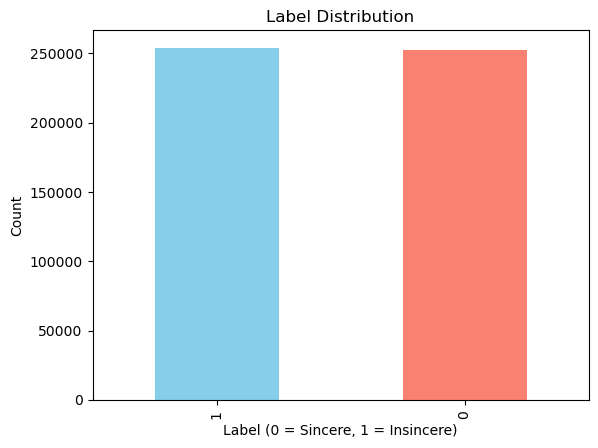

In [37]:
train['labels'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Label Distribution")
plt.xlabel("Label (0 = Sincere, 1 = Insincere)")
plt.ylabel("Count")
plt.show()

after doing all the preprocessing now we can say that the data is balanced

#### Done for preprocessing

## Neural Network model from scratch

I decided that i will work with the RNN model beucause am not working with images am wokring on text and the LSTM  which is a RNN model is designed for sequential data (text has order  and the LSTM understands the order)

In [ ]:
model_scratch = tf.keras.Sequential([
    
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=10000, output_dim=64, input_length=MAX_LEN), #vocab size 10k unique words
    layers.BatchNormalization(),
    layers.Masking(mask_value=0.0), #ignre padded tokens that are equal to 0
    layers.GaussianNoise(0.1), #add random noise so the model can generalize more 
    layers.SpatialDropout1D(0.3),  
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),  
    layers.BatchNormalization(), 
    layers.Dropout(0.4),
    layers.GlobalMaxPooling1D(),  
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
    layers.BatchNormalization(),
    layers.Dropout(0.3),  
    layers.Dense(1, activation='sigmoid')
])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masking (Masking)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 711,617 (2.71 MB)

 Trainable params: 710,913 (2.71 MB)

 Non-trainable params: 704 (2.75 KB)

i did here the model from scratch which have the input + the embedding part so the model excepts sequence of length MAX_LEN and then added layers.embedding which maps each token id into a dense 64 dimensendional vetor

for the regularization part i used batchnormalization because it blocks the noise so the training becomes more stable and also the gaussian noise used to froce the model to geenralize which prevents the overfitting (similar to data augmentation), masking to ignore any padding that = 0 , the dropout to make some neurons disactived and early stopping which reduces also the learning rate -> reduce the overfitting 

and for the outpout summary this is the architectire of the output shape and the params  : trainable params are 710,913 and the non trainable are the moving mean and moving variance statistics used by BatchNormalization layers during inference. They are not trainable weights.

## Model training & Evalutation

In [39]:
history = model_scratch.fit(
    train_padded, y_train,  # Use regular variables - they include augmentation
    epochs=15,
    batch_size=256,
    validation_data=(validation_padded, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 345s 169ms/step - accuracy: 0.8614 - loss: 0.4146 - val_accuracy: 0.9196 - val_loss: 0.2140 - learning_rate: 0.0010
Epoch 2/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 333s 168ms/step - accuracy: 0.8875 - loss: 0.2992 - val_accuracy: 0.8832 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 3/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 335s 169ms/step - accuracy: 0.8946 - loss: 0.2801 - val_accuracy: 0.9008 - val_loss: 0.2445 - learning_rate: 0.0010
Epoch 4/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8984 - loss: 0.2694
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 337s 170ms/step - accuracy: 0.9007 - loss: 0.2647 - val_accuracy: 0.8672 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 5/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 337s 170ms/step - accuracy: 0.9089 - loss: 0.2431 - val_accuracy: 0.8964 - val_loss: 0.2456 - learning_rate: 5.0000e-04
Epoch 6/15
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 334s 169m

here i fitted the model and if we check the training_accuracy and validation accuracy : the model startedto learn prefectly with rate of trainnig : 86% and validation : 91% (which says that there is no overfitting) then the val_accuracy began to decrease alot from 91% to 88% (there a is a little bit of overfittng here) and in the third epoch it began to increase again from epoch 4 the model reduced its learning rate because of the overfitting becuase the val_accuracy decrease from 90% to 86% which is so so bad and it goes like this (increase and then decrease so much) because of the overfitting the eraly stopping did its job and we stopped at epoch 6 the best epoch wa the ifrst one the model was leanring pretty great in it

In [40]:
loss, acc = model_scratch.evaluate(test_padded, y_test)
print("Test Accuracy:", acc)
print("Test Loss:", loss)


1485/1485 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9208 - loss: 0.2113
Test Accuracy: 0.9207789301872253
Test Loss: 0.21131615340709686


the test accuracy is SO SO good comparing it to the validation one

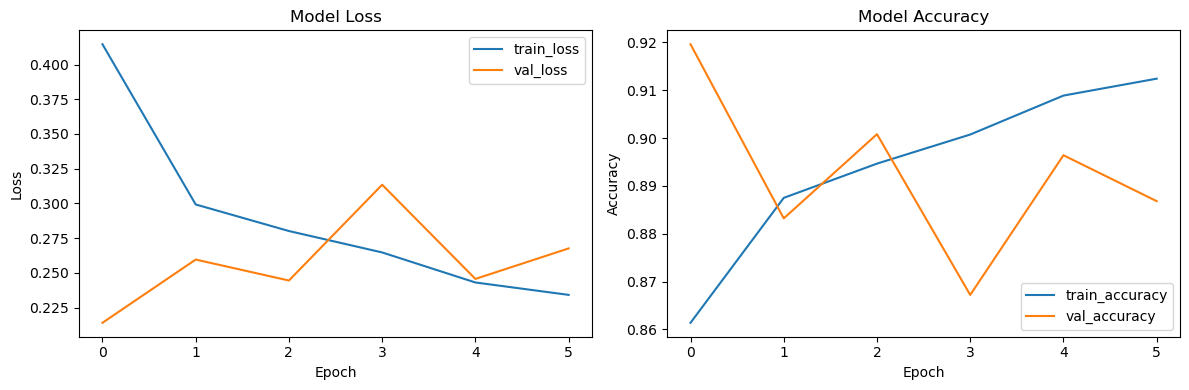

In [41]:
# Use the new plotting function
plot_training_history(history)

actually it's not a very good gap in the model loss between the training and the validtion but the model accuracy is gaped alot

## Pretrained model

since am using a NLP model i can't use VGG16/ResNet because this is for cnn model and not for NLP LSTM -> so i am gonna use GloVE : a method trained on a huge amount of text its goal is to convert each word into a vector of numbers 
-> it's so useful because similar meaning of words have similar vectors, captures relationships,improve accuracy ... we will compare between it and the neural network model from scratch

In [42]:
embedding_index = {} #created a dictionary that will store word -> vector
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split() #this splits the line into a value of strings
        word = values[0] # the word itself
        vector = np.asarray(values[1:], dtype='float32') #converts them into numpy array
        embedding_index[word] = vector #store it in th dict

print("Loaded word vectors:", len(embedding_index))


Loaded word vectors: 400000


this create empty dictioonary that will store word -> vector mapping
so the words from the file that will be embedded are 400000

In [43]:
word_index = tokenizer.word_index  # word -> integer
num_words = min(10000, len(word_index) + 1) # limit 10k top frquent words and +1 bec index 0 is reserved for padding 
embedding_dim = 100

embedding_matrix = np.zeros((num_words, embedding_dim)) # (10k,100)

for word, i in word_index.items():
    if i < num_words:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

            # each row corresponds to a word index in my tokenzier and if not then it will be filled woth zeros


i downloaded GloVe from stanford website -> and i open it here in the notebook
then i did a loop that read the file line by line in glove -> eahc line contain one word and its 100 numbers -> the embedding vector


embedding_index = {
  'king': [0.12, -0.45, 0.33, ..., 0.09],
  'queen': [0.15, -0.48, 0.36, ..., 0.11],
  'cat': [0.21, -0.12, 0.55, ..., -0.08],
}

In [44]:
print("APPLYING STANDARD SCALING TO EMBEDDINGS")


def normalize_embeddings(embedding_matrix):
    """Apply Standard Scaling to embedding vectors"""
    scaler = StandardScaler()
    orig_shape = embedding_matrix.shape
    flattened = embedding_matrix.reshape(-1, 1)
    normalized = scaler.fit_transform(flattened)
    return normalized.reshape(orig_shape)

print("Normalizing Word2Vec embeddings...")
word2vec_matrix_normalized = normalize_embeddings(word2vec_matrix)

print("Normalizing GloVe embeddings...")
embedding_matrix_normalized = normalize_embeddings(embedding_matrix)

print("✓ Embeddings normalized with StandardScaler")

APPLYING STANDARD SCALING TO EMBEDDINGS
Normalizing Word2Vec embeddings...
Normalizing GloVe embeddings...
✓ Embeddings normalized with StandardScaler


this normalizes the embedding matrices using standard scaler : mean = 0 and the standard deviation = 1 which helps the neural networks learn better

In [ ]:
model_glove = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix_normalized],
        input_length=MAX_LEN,
        trainable=True
    ),
    
    layers.BatchNormalization(),

    # Add Spatial Dropout
    layers.SpatialDropout1D(0.2), 
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

# Keep your existing callbacks and compilation
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

model_glove.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_glove.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089,681 (4.16 MB)

 Trainable params: 1,089,161 (4.15 MB)

 Non-trainable params: 520 (2.03 KB)

here we are training the model from glove and used trainable false to free the weights , to not change them during the training because we are doing transfer learning and then did the same thing dropout, dense and then i compiled as before

In [46]:
history_glove = model_glove.fit(
    train_padded, y_train,  # Same augmented data used here
    validation_data=(validation_padded, y_val),
    batch_size=64,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 467s 58ms/step - accuracy: 0.8602 - loss: 0.3538 - val_accuracy: 0.8660 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 2/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 478s 60ms/step - accuracy: 0.8848 - loss: 0.2962 - val_accuracy: 0.8748 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 3/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 490s 62ms/step - accuracy: 0.8905 - loss: 0.2822 - val_accuracy: 0.8896 - val_loss: 0.2837 - learning_rate: 0.0010
Epoch 4/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 489s 62ms/step - accuracy: 0.8952 - loss: 0.2724 - val_accuracy: 0.8872 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 5/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 495s 63ms/step - accuracy: 0.8982 - loss: 0.2652 - val_accuracy: 0.8904 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 6/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 506s 64ms/step - accuracy: 0.9010 - loss: 0.2581 - val_accuracy: 0.8872 - val_loss: 0.2768 - learning_rate: 0.0010
Epoch 7/15
7916/7916 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - a

for the first 3 epochs the model was learning so good and the val accuracy >> than the training one but from the 4th the model's performance degrades so the model reduced its learning rate and still there was overfitting but for sure better than better so we stopped by epoch 14 because there is no change asnd the best epoch was epoch 11

In [47]:
loss_glove, acc_glove = model_glove.evaluate(test_padded, y_test)
print("Test Accuracy:", acc_glove)
print("Test Loss:", loss_glove)

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8995 - loss: 0.2597
Test Accuracy: 0.8995368480682373
Test Loss: 0.2596896290779114


the test accuracy here comparing it to the model from scratch is less than it so for now the testing of the scartch is better

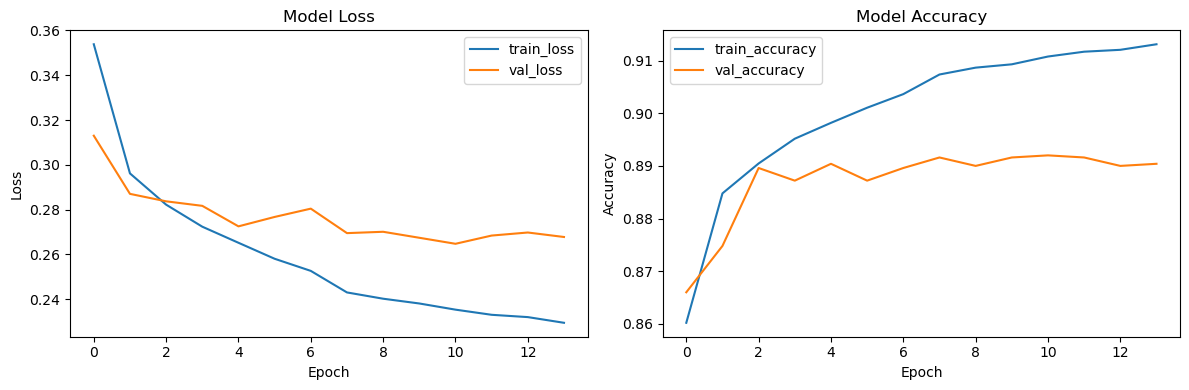

In [48]:
# Use the new plotting function for glove model too
plot_training_history(history_glove)

the gap here is bigger than in the from scratch one 

## Word2vec model

here i will train the model  is like a pretrained model that i will use to compare between the 3 models (scratch , pretrained and the word2vec)

In [49]:
print("CREATING WORD2VEC MODEL")

model_word2vec = tf.keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    # Embedding layer using our Word2Vec matrix
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[word2vec_matrix_normalized],  # Use Word2Vec weights
        input_length=MAX_LEN,
        trainable=False  # Don't update Word2Vec weights during training
    ),
    
    layers.BatchNormalization(),

    # Keep your same architecture
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.GlobalMaxPooling1D(),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# Compile with same settings
model_word2vec.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_word2vec.summary()

CREATING WORD2VEC MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,065 (4.16 MB)

 Trainable params: 89,353 (349.04 KB)

 Non-trainable params: 1,000,712 (3.82 MB)

here the non-trainable parameters are too much!!

In [50]:
# Train
print("\nTraining Word2Vec model...")
history_word2vec = model_word2vec.fit(
    train_padded, y_train,
    epochs=10,
    batch_size=256,
    validation_data=(validation_padded, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Training Word2Vec model...
Epoch 1/10
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 553s 276ms/step - accuracy: 0.8398 - loss: 0.3964 - val_accuracy: 0.9176 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 2/10
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 481s 243ms/step - accuracy: 0.8618 - loss: 0.3437 - val_accuracy: 0.9000 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 3/10
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8664 - loss: 0.3354
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 485s 245ms/step - accuracy: 0.8675 - loss: 0.3321 - val_accuracy: 0.8924 - val_loss: 0.2651 - learning_rate: 0.0010
Epoch 4/10
1979/1979 ━━━━━━━━━━━━━━━━━━━━ 492s 249ms/step - accuracy: 0.8705 - loss: 0.3241 - val_accuracy: 0.8992 - val_loss: 0.2389 - learning_rate: 2.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


the model started very good with the val_accuracy >> than the training one but the val_accuracy degrades as we do more epoch (but still it's better than the training one) so on epoch 3 we reduced the learning rate and it still degrades so we stopped the training  on epoch 4 and th best epoch was 1

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9238 - loss: 0.1943
WORD2VEC MODEL RESULTS
Test Accuracy: 0.9238
Test Loss: 0.1943
ALL MODEL COMPARISON
1. Scratch Model:      Test Acc = 0.9208, Loss = 0.2113
2. GloVe Model:        Test Acc = 0.8995, Loss = 0.2597
3. Word2Vec Model:     Test Acc = 0.9238, Loss = 0.1943


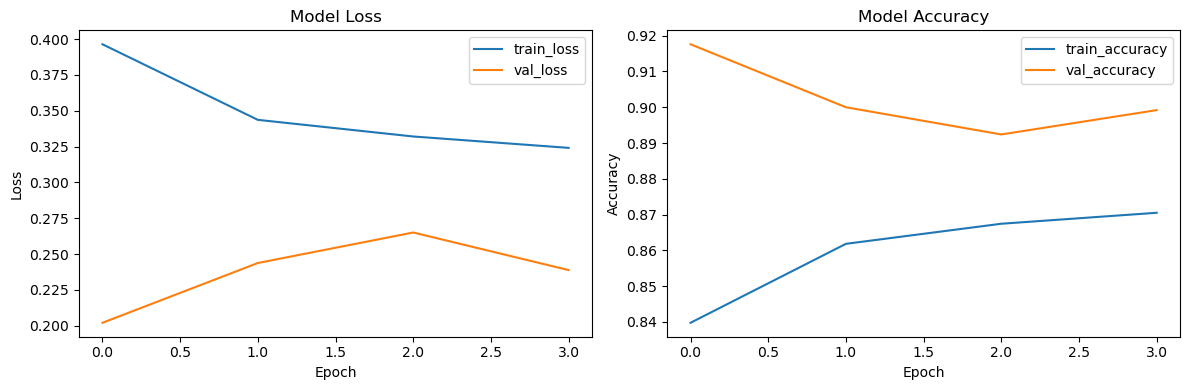


✓ Word2Vec model saved as 'model_word2vec.h5'


In [51]:
# Test
loss_w2v, acc_w2v = model_word2vec.evaluate(test_padded, y_test)
print("WORD2VEC MODEL RESULTS")
print(f"Test Accuracy: {acc_w2v:.4f}")
print(f"Test Loss: {loss_w2v:.4f}")


print("ALL MODEL COMPARISON")
print(f"1. Scratch Model:      Test Acc = {acc:.4f}, Loss = {loss:.4f}")
print(f"2. GloVe Model:        Test Acc = {acc_glove:.4f}, Loss = {loss_glove:.4f}")
print(f"3. Word2Vec Model:     Test Acc = {acc_w2v:.4f}, Loss = {loss_w2v:.4f}")

# Plot results
plot_training_history(history_word2vec)

# Save model
model_word2vec.save("model_word2vec.h5")
print("\n✓ Word2Vec model saved as 'model_word2vec.h5'")

the test accuracy was the best (better than the model from scratch and the glove model)

### Comparison between the model from scratch and the pretrained one

#### Overview:
- model from scratch:
embedding layer , two LSTM layers , batch normalization and dense layer

- pretrained glove model:
100 dim pretrained word vectors , embedding layer is frozen (non trainable) , one LSTM layer and a dense classifier 

- word2vec model:
bidirectional LSTM layer , batch normalixation , dropout and spatial dropout

i trained both models on 15 epochs ...


### Performance comparison:
the validation accuracy on the first epoch -> from scratch: almost 92% best accuracy 

the validation accuracy on the first epoch -> from pretrained: 86% the worst

the validation accuracy on the first epoch -> from word2vec: 91% good


test accuracy -> from scratch:  92.07% good
                    
test accuracy -> from pretrained: 90% the worst 

test accuracy -> from word2vec: 92.38% the best


#### so worde2vec performed better in testing which says that this is the best model
                        

In [52]:
model_glove.save("model_glove.h5")


In [53]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)



In [54]:
print("FINAL MODEL COMPARISON")


# Calculate overfitting gaps
scratch_gap = (history.history['accuracy'][-1] - history.history['val_accuracy'][-1]) * 100
glove_gap = (history_glove.history['accuracy'][-1] - history_glove.history['val_accuracy'][-1]) * 100
word2vec_gap = (history_word2vec.history['accuracy'][-1] - history_word2vec.history['val_accuracy'][-1]) * 100

print("\nOVERFITTING ANALYSIS:")
print(f"Scratch Model overfitting gap: {scratch_gap:.2f}%")
print(f"GloVe Model overfitting gap: {glove_gap:.2f}%")
print(f"Word2Vec Model overfitting gap: {word2vec_gap:.2f}%")


print("FINAL RESULTS SUMMARY")
print(f"{'Model':<25} {'Test Acc':<12} {'Test Loss':<12} {'Overfit Gap':<12}")
print("-"*60)
print(f"{'Scratch Model':<25} {acc:<12.4f} {loss:<12.4f} {scratch_gap:<12.2f}%")
print(f"{'GloVe Model':<25} {acc_glove:<12.4f} {loss_glove:<12.4f} {glove_gap:<12.2f}%")
print(f"{'Word2Vec Model':<25} {acc_w2v:<12.4f} {loss_w2v:<12.4f} {word2vec_gap:<12.2f}%")

# Determine best model
if acc_w2v >= acc_glove and acc_w2v >= acc:
    best_model = "Word2Vec"
    print(f"\nBEST MODEL: {best_model} with {acc_w2v:.4f} test accuracy")
elif acc_glove >= acc:
    best_model = "GloVe"
    print(f"\nBEST MODEL: {best_model} with {acc_glove:.4f} test accuracy")
else:
    best_model = "Scratch"
    print(f"\nBEST MODEL: {best_model} with {acc:.4f} test accuracy")

# Save models
print("\nSaving models...")
model_scratch.save("model_scratch.h5")
model_glove.save("model_glove.h5")
model_word2vec.save("model_word2vec.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

FINAL MODEL COMPARISON

OVERFITTING ANALYSIS:
Scratch Model overfitting gap: 2.56%
GloVe Model overfitting gap: 2.27%
Word2Vec Model overfitting gap: -2.87%
FINAL RESULTS SUMMARY
Model                     Test Acc     Test Loss    Overfit Gap 
------------------------------------------------------------
Scratch Model             0.9208       0.2113       2.56        %
GloVe Model               0.8995       0.2597       2.27        %
Word2Vec Model            0.9238       0.1943       -2.87       %

BEST MODEL: Word2Vec with 0.9238 test accuracy

Saving models...


as i told you that the best model that performed is the word2vec model